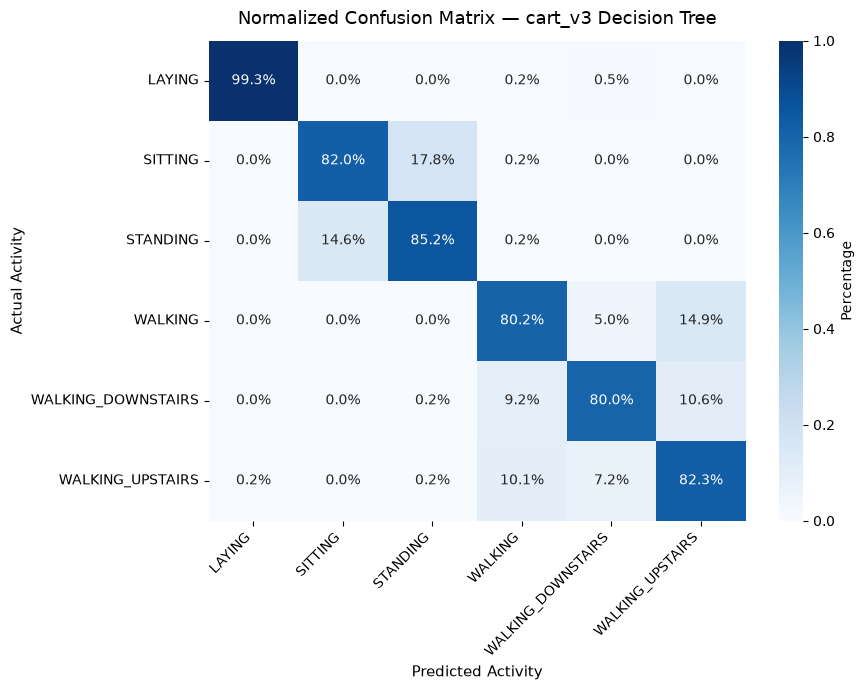

In [2]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the first record from your JSONL file
with open("model_results.jsonl", "r") as f:
    run_data = json.loads(f.readline())

# 2. Extract metadata using your exact JSON keys
model_name = run_data["model"]
activity_labels = run_data["classes"]
cm_normalized = np.array(run_data["confusion_matrix_percent"], dtype=float)

# 3. Plot normalized confusion matrix
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1%",           # Automatically formats 0.9933 -> 99.3%
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    xticklabels=activity_labels,
    yticklabels=activity_labels,
    cbar_kws={"label": "Percentage"}
)

plt.title(f"Normalized Confusion Matrix — {model_name}", fontsize=13, pad=12)
plt.xlabel("Predicted Activity", fontsize=11)
plt.ylabel("Actual Activity", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# 4. Save image for PDF inclusion
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()